# House Price Prediction

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

Now i am importing Boston housing dataset

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv")

In [ ]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
df.shape

(506, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [ ]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
df.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


In [ ]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [ ]:
X = df[['rm', 'lstat', 'ptratio']]
y = df['medv']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
sscaler = StandardScaler()
x_train = sscaler.fit_transform(x_train)
x_test = sscaler.transform(x_test)


EDA

Scatter Plot

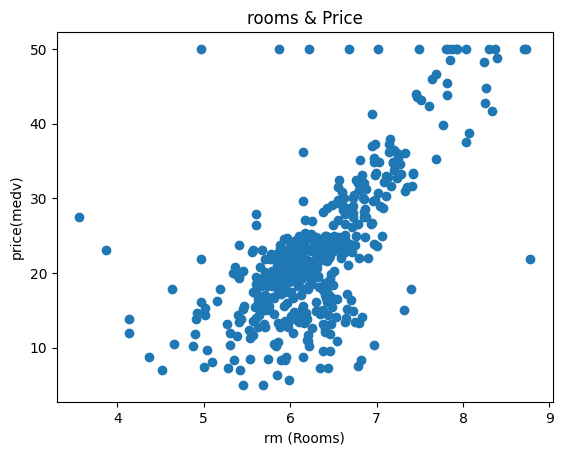

In [ ]:
plt.scatter(df['rm'],df['medv'])
plt.xlabel('rm (Rooms)')
plt.ylabel('price(medv)')
plt.title("rooms & Price")
plt.show()

Histogram of price

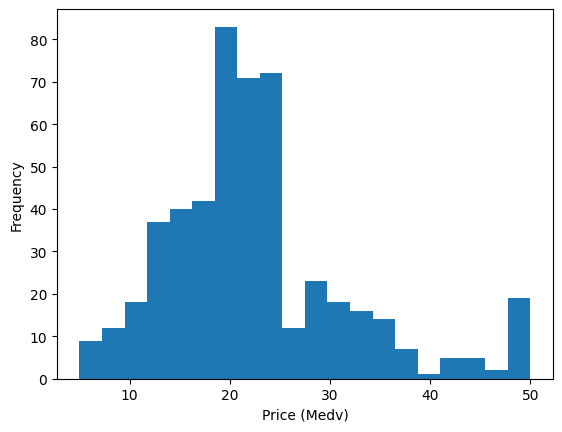

In [ ]:
plt.hist(df['medv'],bins=20)
plt.xlabel('Price (Medv)')
plt.ylabel('Frequency')
plt.show()

Heat Map

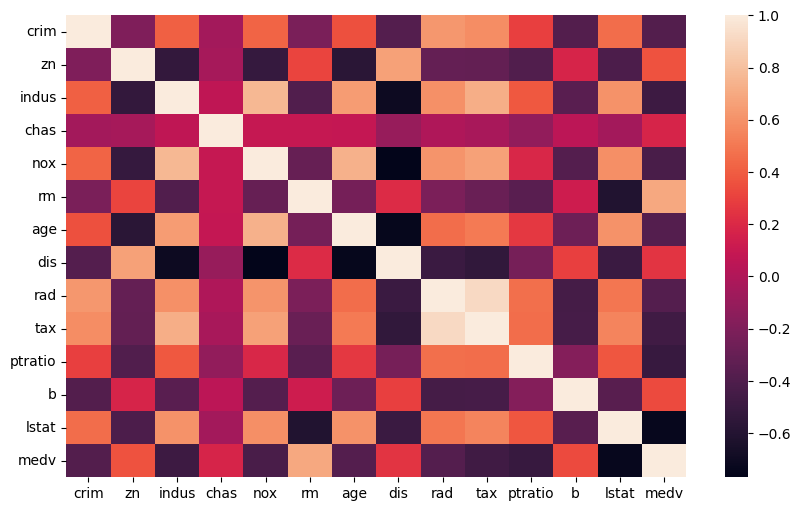

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=False)
plt.show()

Model Selection

In [ ]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_predict=model.predict(x_test)

Evaluation metrics

In [ ]:
msa = mean_absolute_error(y_test,y_predict)
mea = mean_squared_error(y_test,y_predict)
rmse = np.sqrt(mea)
r2 = r2_score(y_test,y_predict)

print("Mean Absolute Error:",msa)
print("Mean Squared Error:",mea)
print("Root Mean Squared Error:",rmse)
print("R2 Score:",r2)

Mean Absolute Error: 3.3325380783240965
Mean Squared Error: 27.114957415580562
Root Mean Squared Error: 5.207202455789535
R2 Score: 0.6302528487272829


visualization of Actual and predicted value

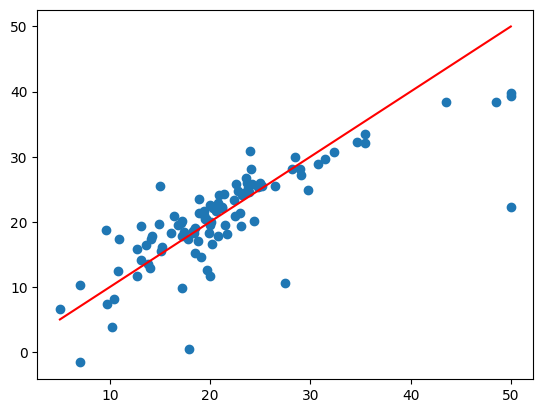

In [ ]:
plt.scatter(y_test, y_predict)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.show()

Histogram of Error rate

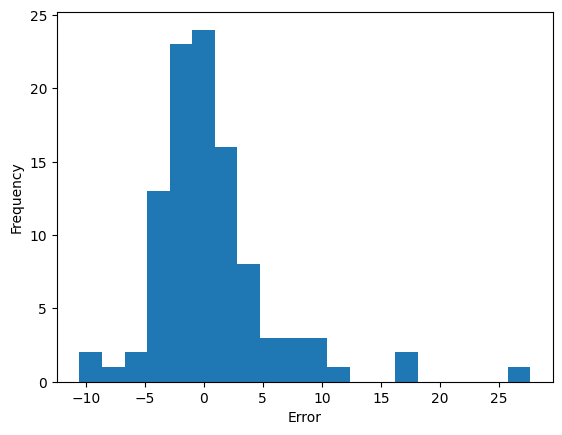

In [ ]:
error = y_test-y_predict
plt.hist(error,bins = 20)
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

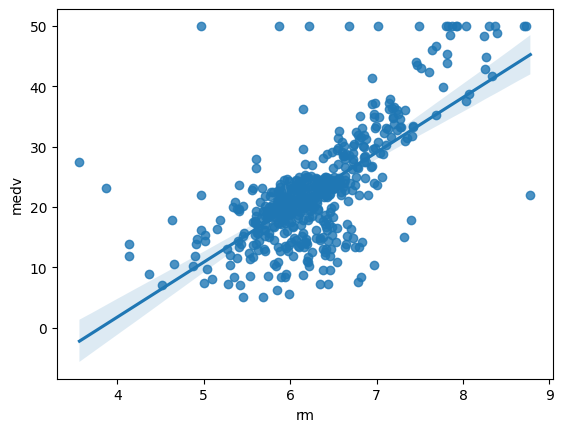

In [ ]:
sns.regplot(x='rm', y='medv', data=df)
plt.show()

In [ ]:
coefficients = pd.DataFrame(model.coef_, ['rm','lstat','ptratio'], columns=['Coefficient'])
print(coefficients)

         Coefficient
rm          3.495475
lstat      -4.027487
ptratio    -1.930102


Saving the model

In [ ]:
import pickle
pickle.dump(model,open("house_Price_Pred","wb"))


# Conclusion

In this project, I built a Machine Learning model to predict house prices based on important features such as number of rooms (rm), lower status population percentage (lstat), and pupil-teacher ratio (ptratio).

I started with data understanding and preprocessing, including handling missing values and analyzing feature correlations. After selecting the most relevant features, I split the dataset into training and testing sets and applied feature scaling to improve model performance.

I trained a Linear Regression model and evaluated it using metrics such as MAE, MSE, RMSE, and R² Score. The model demonstrated a good ability to capture the relationship between features and house prices.

To further improve performance, I experimented with advanced models like Random Forest and Polynomial Regression.i can also use these models that gave me the better result but according to fyp instructions i am using the linear regression model

Overall, this project helped me build a strong foundation in regression techniques, feature engineering, and model evaluation, which are essential skills in Machine Learning and Artificial Intelligence.